energy_001_allmag.csv: 26 states, 63 edges, 239 complete paths
energy_011_12.csv: 27 states, 66 edges, 255 complete paths
energy_011_34.csv: 27 states, 66 edges, 255 complete paths


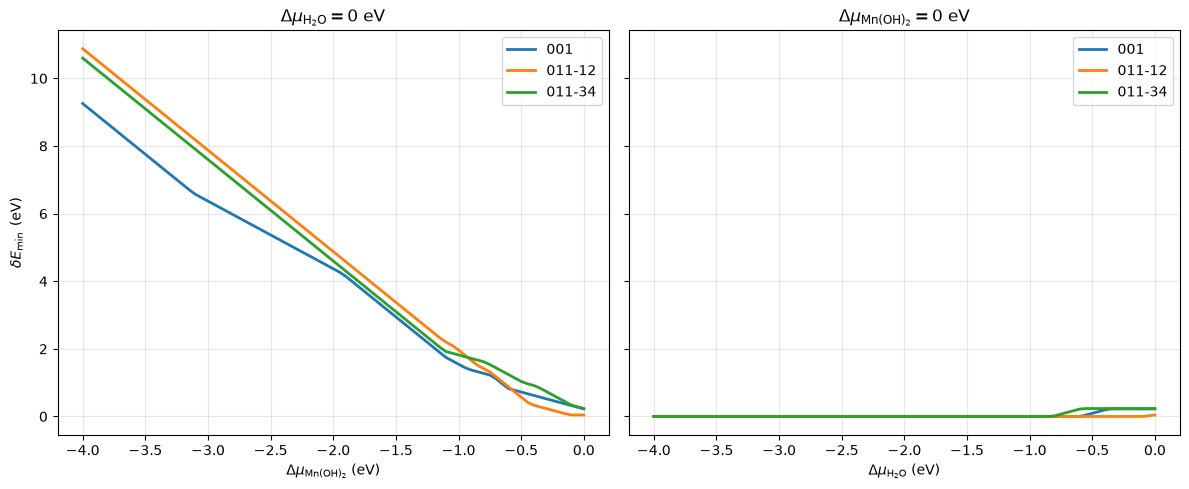

In [ ]:
# ============================================================
# Compare minimum energetic span:
# 001 / 011_12 / 011_34
# ============================================================

from pathlib import Path
from collections import defaultdict

import csv
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 0. INPUT
# ============================================================

DATASETS = {
    "001": "energy_001_allmag.csv",
    "011-12": "energy_011_12.csv",
    "011-34": "energy_011_34.csv",
}

START_STATE = "S000"
FINAL_STATE = "S322"

MU_MIN = -4.0
MU_MAX = 0.0
MU_STEP = 0.05

# left graph
FIXED_MU_H2O = 0.0

# right graph
FIXED_MU_MN = 0.0

TIE_TOLERANCE_EV = 1e-6


# ============================================================
# 1. LOAD ENERGY CSV
# ============================================================

def load_states(csv_file):

    data = []

    with open(
        csv_file,
        newline="",
        encoding="utf-8-sig",
    ) as f:

        reader = csv.DictReader(f)

        required = {
            "state",
            "coordinate",
            "relative_E",
        }

        missing = (
            required
            - set(reader.fieldnames or [])
        )

        if missing:

            raise ValueError(
                f"{csv_file}: "
                f"missing columns {missing}"
            )


        for row in reader:

            state = row["state"].strip()

            energy_text = (
                row["relative_E"].strip()
            )


            # energy가 없는 state는 skip
            if (
                not state
                or not energy_text
            ):
                continue


            # S211 -> O=2, C=1, X=1
            O, C, X = map(
                int,
                state[1:]
            )


            data.append({

                "state":
                    state,

                "coordinate":
                    float(
                        row["coordinate"]
                    ),

                "E0":
                    float(
                        energy_text
                    ),

                "O":
                    O,

                "C":
                    C,

                "X":
                    X,

            })


    data.sort(
        key=lambda s: (
            s["coordinate"],
            s["state"],
        )
    )

    return data


# ============================================================
# 2. REACTION NETWORK
# ============================================================

def classify_transition(
    initial,
    final,
):

    dO = (
        final["O"]
        - initial["O"]
    )

    dC = (
        final["C"]
        - initial["C"]
    )

    dX = (
        final["X"]
        - initial["X"]
    )


    if (dO, dC, dX) == (1, 0, 0):

        return "OL"


    if (dO, dC, dX) == (0, 1, 0):

        return "C"


    if (dO, dC, dX) == (0, 0, 1):

        return "SR"


    if (dO, dC, dX) == (1, 1, 0):

        return "OX"


    return None


# ============================================================
# 3. BUILD ALL EDGES
#    Energetic-span 계산에는 ΔG < 1 eV 필터 없음
# ============================================================

def build_all_edges(states):

    edges = []


    for a in states:

        for b in states:

            if (
                b["coordinate"]
                <= a["coordinate"]
            ):
                continue


            transition = (
                classify_transition(
                    a,
                    b,
                )
            )


            if transition is None:
                continue


            # OL/C/SR = coordinate +1
            # OX      = coordinate +2

            expected_dx = (
                2
                if transition == "OX"
                else 1
            )


            dx = (
                b["coordinate"]
                - a["coordinate"]
            )


            if math.isclose(
                dx,
                expected_dx,
                abs_tol=1e-12,
            ):

                edges.append(
                    (
                        a["state"],
                        b["state"],
                        transition,
                    )
                )


    return edges


# ============================================================
# 4. ENUMERATE ALL COMPLETE PATHS
# ============================================================

def enumerate_all_paths(
    edges,
    start=START_STATE,
    final=FINAL_STATE,
):

    adjacency = defaultdict(list)


    for a, b, mechanism in edges:

        adjacency[a].append(
            (
                b,
                mechanism,
            )
        )


    for state in adjacency:

        adjacency[state].sort()


    paths = []


    def dfs(
        current,
        state_sequence,
        mechanism_sequence,
    ):

        if current == final:

            paths.append({

                "states":
                    state_sequence.copy(),

                "mechanisms":
                    mechanism_sequence.copy(),

            })

            return


        for (
            next_state,
            mechanism,
        ) in adjacency.get(
            current,
            []
        ):


            if (
                next_state
                in state_sequence
            ):
                continue


            dfs(

                next_state,

                state_sequence
                + [next_state],

                mechanism_sequence
                + [mechanism],

            )


    dfs(
        start,
        [start],
        [],
    )


    # ID 부여
    for i, path in enumerate(
        paths,
        start=1,
    ):

        path["path_id"] = (
            f"P{i:03d}"
        )


    return paths


# ============================================================
# 5. STATE ENERGY COEFFICIENT
#
# G =
# E0
# - O * mu_Mn
# + (C + X/2) * mu_H2O
#
# = A + B*mu_Mn + C*mu_H2O
# ============================================================

def state_coeff(state):

    return np.array([

        state["E0"],

        -state["O"],

        (
            state["C"]
            + 0.5 * state["X"]
        ),

    ], dtype=float)


# ============================================================
# 6. PRECOMPILE ONE PATH
# ============================================================

def compile_path(
    path,
    smap,
    dGr_coeff,
):

    # final state는 TDI / TDTS candidate에서 제외
    names = path["states"][:-1]


    coeffs = np.array([

        state_coeff(
            smap[name]
        )

        for name in names

    ])


    terms = []
    pairs = []


    for i in range(
        len(names)
    ):

        for j in range(
            len(names)
        ):


            term = (
                coeffs[i]
                - coeffs[j]
            )


            # 기존에 사용하던 ESM convention 유지
            if i < j:

                term = (
                    term
                    + dGr_coeff
                )


            terms.append(term)

            pairs.append(
                (
                    names[j],  # TDI
                    names[i],  # TDTS
                )
            )


    return {

        "path_id":
            path["path_id"],

        "states":
            path["states"],

        "mechanisms":
            path["mechanisms"],

        "terms":
            np.array(terms),

        "pairs":
            pairs,

    }


# ============================================================
# 7. PREPARE ONE DATASET
# ============================================================

def prepare_dataset(csv_file):

    states = load_states(
        csv_file
    )


    smap = {

        s["state"]: s

        for s in states

    }


    if START_STATE not in smap:

        raise ValueError(
            f"{csv_file}: "
            f"{START_STATE} missing"
        )


    if FINAL_STATE not in smap:

        raise ValueError(
            f"{csv_file}: "
            f"{FINAL_STATE} missing"
        )


    edges = build_all_edges(
        states
    )


    paths = enumerate_all_paths(
        edges
    )


    # 모든 complete path의 start/final이 동일하므로
    # ΔGr coefficient도 동일

    dGr_coeff = (

        state_coeff(
            smap[FINAL_STATE]
        )

        - state_coeff(
            smap[START_STATE]
        )

    )


    compiled_paths = [

        compile_path(
            path,
            smap,
            dGr_coeff,
        )

        for path in paths

    ]


    print(
        f"{csv_file}: "
        f"{len(states)} states, "
        f"{len(edges)} edges, "
        f"{len(paths)} complete paths"
    )


    return compiled_paths


# ============================================================
# 8. δE FOR ONE PATH
# ============================================================

def evaluate_path(
    path,
    mu_mn,
    mu_h2o,
):

    condition = np.array([
        1.0,
        mu_mn,
        mu_h2o,
    ])


    # 모든 TDI/TDTS candidate를 한 번에 계산
    values = (
        path["terms"]
        @ condition
    )


    idx = np.argmax(
        values
    )


    return {

        "deltaE":
            values[idx],

        "TDI":
            path["pairs"][idx][0],

        "TDTS":
            path["pairs"][idx][1],

        "path_id":
            path["path_id"],

    }


# ============================================================
# 9. δEmin AMONG ALL PATHS
# ============================================================

def find_dEmin(
    compiled_paths,
    mu_mn,
    mu_h2o,
):

    results = [

        evaluate_path(
            path,
            mu_mn,
            mu_h2o,
        )

        for path
        in compiled_paths

    ]


    min_value = min(

        r["deltaE"]

        for r in results

    )


    best_paths = [

        r

        for r in results

        if abs(
            r["deltaE"]
            - min_value
        )
        <= TIE_TOLERANCE_EV

    ]


    return (
        min_value,
        best_paths,
    )


# ============================================================
# 10. SCAN ONE DATASET
# ============================================================

def scan_dataset(
    compiled_paths,
    mu_values,
):

    dE_mn = []
    dE_h2o = []


    for mu in mu_values:


        # -----------------------------------------
        # Mn(OH)2 scan
        # H2O = 0
        # -----------------------------------------

        dEmin, _ = find_dEmin(

            compiled_paths,

            mu_mn=mu,

            mu_h2o=FIXED_MU_H2O,

        )

        dE_mn.append(
            dEmin
        )


        # -----------------------------------------
        # H2O scan
        # Mn(OH)2 = 0
        # -----------------------------------------

        dEmin, _ = find_dEmin(

            compiled_paths,

            mu_mn=FIXED_MU_MN,

            mu_h2o=mu,

        )

        dE_h2o.append(
            dEmin
        )


    return (
        np.array(dE_mn),
        np.array(dE_h2o),
    )


# ============================================================
# 11. CALCULATE ALL THREE DATASETS
# ============================================================

mu_values = np.arange(

    MU_MIN,

    MU_MAX
    + MU_STEP / 2,

    MU_STEP,

)


results = {}


for label, csv_file in DATASETS.items():


    compiled_paths = (
        prepare_dataset(
            csv_file
        )
    )


    dE_mn, dE_h2o = (
        scan_dataset(
            compiled_paths,
            mu_values,
        )
    )


    results[label] = {

        "MnOH2":
            dE_mn,

        "H2O":
            dE_h2o,

    }


# ============================================================
# 12. MATPLOTLIB
# ============================================================

fig, axes = plt.subplots(

    1,
    2,

    figsize=(12, 5),

    sharey=True,

)


# ------------------------------------------------------------
# Mn(OH)2
# ------------------------------------------------------------

ax = axes[0]


for label in DATASETS:

    ax.plot(

        mu_values,

        results[label]["MnOH2"],

        linewidth=2,

        label=label,

    )


ax.set_xlabel(
    r"$\Delta\mu_{\mathrm{Mn(OH)_2}}$ (eV)"
)

ax.set_ylabel(
    r"$\delta E_{\min}$ (eV)"
)

ax.set_title(
    r"$\Delta\mu_{\mathrm{H_2O}} = 0$ eV"
)

ax.grid(
    True,
    alpha=0.3,
)

ax.legend()


# ------------------------------------------------------------
# H2O
# ------------------------------------------------------------

ax = axes[1]


for label in DATASETS:

    ax.plot(

        mu_values,

        results[label]["H2O"],

        linewidth=2,

        label=label,

    )


ax.set_xlabel(
    r"$\Delta\mu_{\mathrm{H_2O}}$ (eV)"
)

ax.set_title(
    r"$\Delta\mu_{\mathrm{Mn(OH)_2}} = 0$ eV"
)

ax.grid(
    True,
    alpha=0.3,
)

ax.legend()


plt.tight_layout()

plt.savefig(
    "dEmin_001_011_comparison.png",
    dpi=300,
    bbox_inches="tight",
)


plt.show()